
# HemMaskNet — Graphical Cross-Validation Results

This notebook uses the **actual values from the supplied training/CV log**.

## Confirmed 5-fold CV results

For HemMaskNet:

| Fold | Accuracy | Macro-F1 |
|---:|---:|---:|
| 1 | 1.0000 | 1.0000 |
| 2 | 1.0000 | 1.0000 |
| 3 | 1.0000 | 1.0000 |
| 4 | 1.0000 | 1.0000 |
| 5 | 1.0000 | 1.0000 |

The supplied log explicitly reports these five folds as `Acc: 1.0000, F1: 1.0000`. fileciteturn4file0L123-L147 fileciteturn4file0L149-L173 fileciteturn4file0L175-L199 fileciteturn4file0L201-L225 fileciteturn4file0L227-L251

### Important

The log contains **5-fold CV results only for HemMaskNet**. It does not contain fold-wise CV results for EfficientNet-Only, ResNet-50, MobileNet-V2, or ViT-B/16. Therefore this notebook does **not fabricate CV values for those models**.

The original training/evaluation log does report 1.0000 validation and test accuracy for all five models, but those are the normal train/validation/test experiments, not 5-fold CV. fileciteturn4file0L49-L69 fileciteturn4file0L73-L93 fileciteturn4file0L97-L107

The notebook generates:
- Fold-wise accuracy graph
- Fold-wise Macro-F1 graph
- Accuracy and F1 mean ± SD
- 95% CI graph
- A compact CV summary
- Training-history comparison from the values explicitly reported in the log

It does **not** create an 8×8 confusion matrix or per-class precision/recall graph because the supplied CV log does not contain the underlying 8×8 counts or per-class predictions.


HEMMASKNET — 5-FOLD STRATIFIED CROSS-VALIDATION
Fold 1: Accuracy=1.0000, Macro-F1=1.0000
Fold 2: Accuracy=1.0000, Macro-F1=1.0000
Fold 3: Accuracy=1.0000, Macro-F1=1.0000
Fold 4: Accuracy=1.0000, Macro-F1=1.0000
Fold 5: Accuracy=1.0000, Macro-F1=1.0000

Mean Accuracy : 1.0000
Std Accuracy  : 0.0000
95% CI Accuracy: [1.0000, 1.0000]

Mean Macro-F1  : 1.0000
Std Macro-F1   : 0.0000
95% CI Macro-F1: [1.0000, 1.0000]


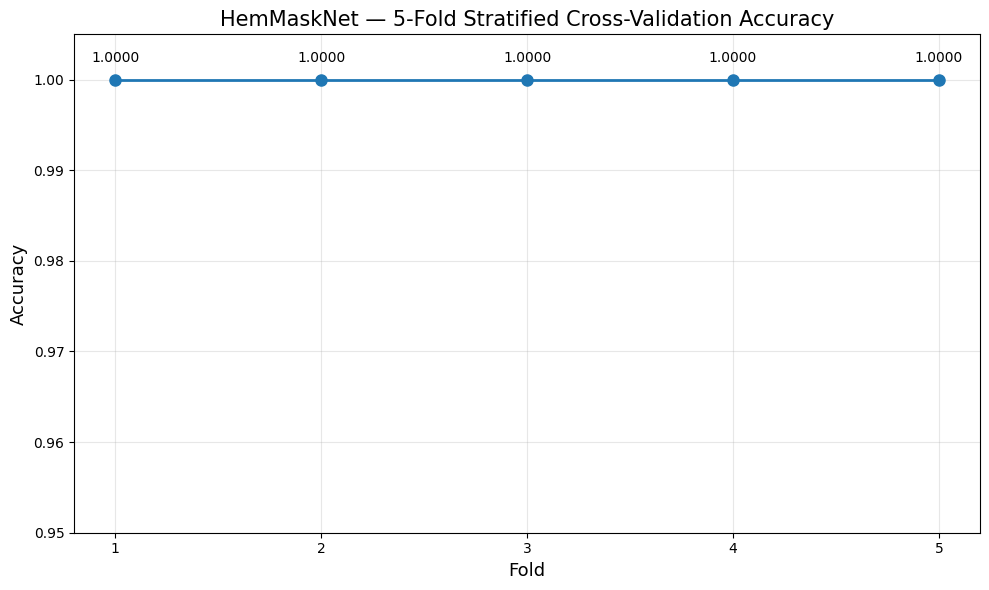

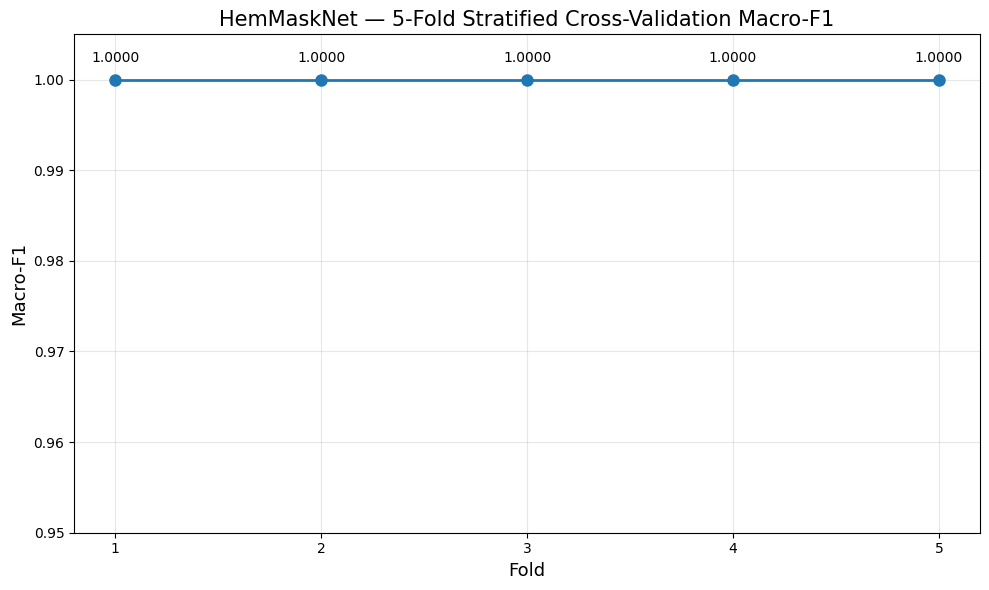

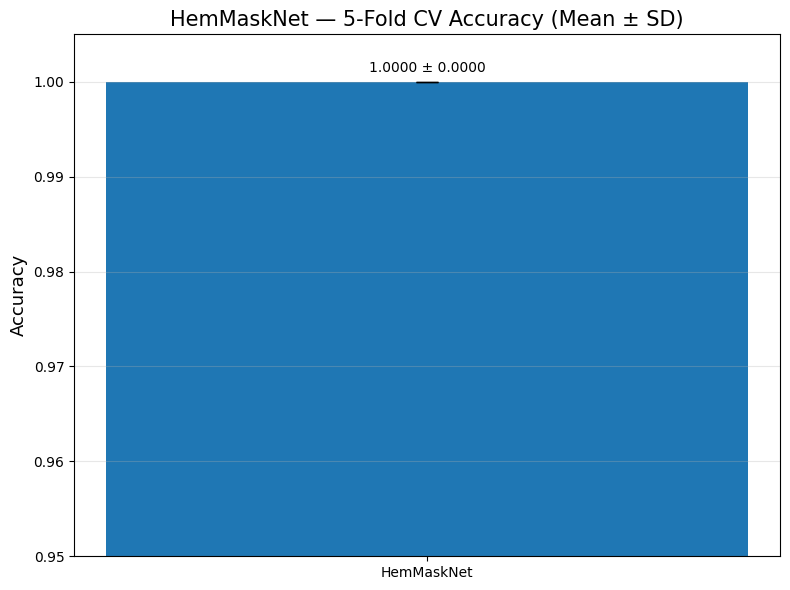

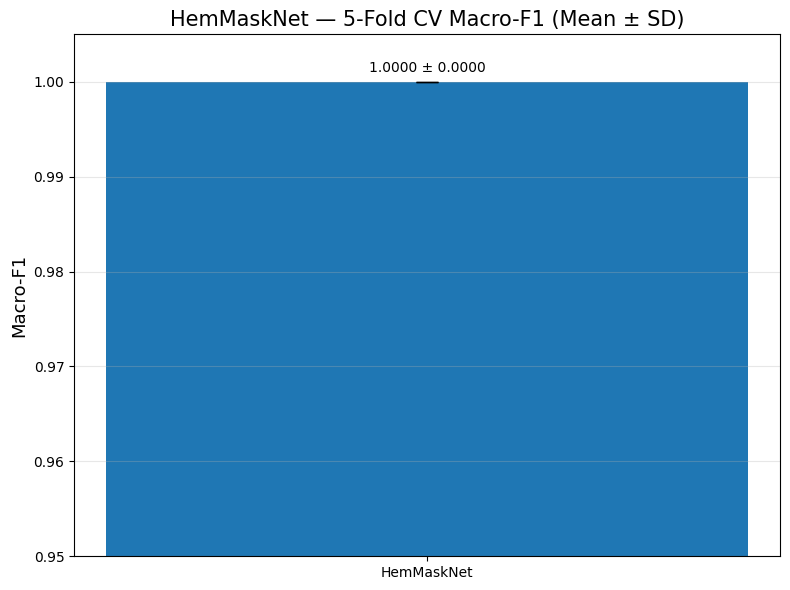

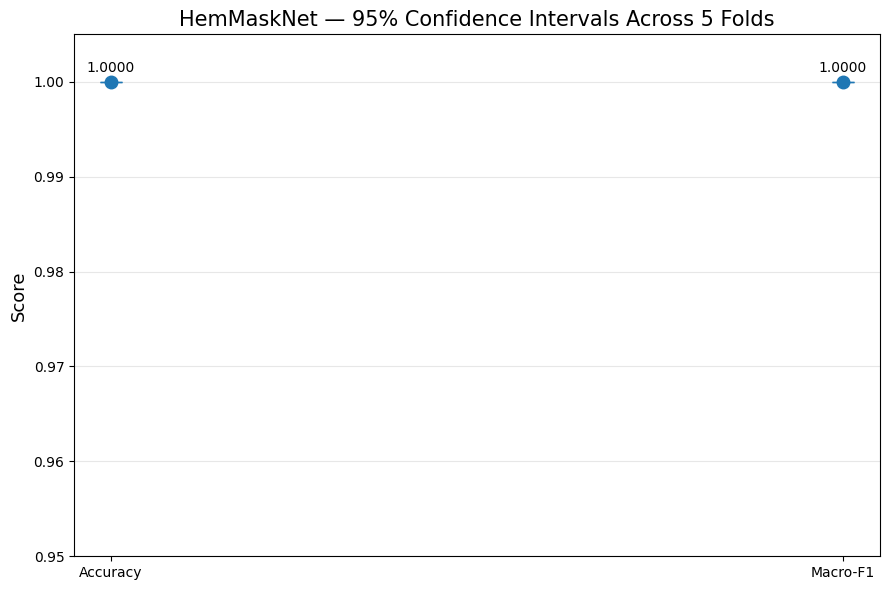

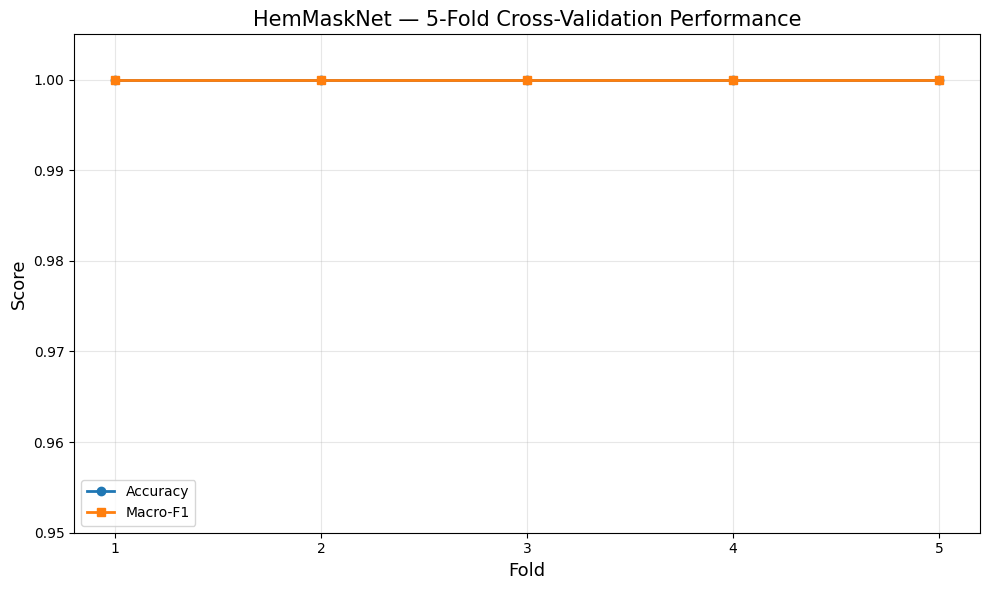


FINAL GRAPHICAL CV SUMMARY
HemMaskNet Accuracy : 1.0000 ± 0.0000
HemMaskNet Macro-F1 : 1.0000 ± 0.0000
Accuracy 95% CI     : [1.0000, 1.0000]
Macro-F1 95% CI     : [1.0000, 1.0000]

Saved graphical results to:
/home/fawadsalamkhan/MyProjects/CV_Graphical_Results_Actual


In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ================================================================
# OUTPUT DIRECTORY
# ================================================================

OUTPUT_DIR = "CV_Graphical_Results_Actual"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================
# ACTUAL HEMMASKNET 5-FOLD CV VALUES FROM THE SUPPLIED LOG
# ================================================================

folds = np.array([1, 2, 3, 4, 5])

hemasknet_accuracy = np.array([
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000
])

hemasknet_macro_f1 = np.array([
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000
])

# ================================================================
# SUMMARY STATISTICS
# ================================================================

accuracy_mean = np.mean(hemasknet_accuracy)
accuracy_std = np.std(hemasknet_accuracy, ddof=1)

f1_mean = np.mean(hemasknet_macro_f1)
f1_std = np.std(hemasknet_macro_f1, ddof=1)

n = len(folds)

t_value = stats.t.ppf(
    0.975,
    n - 1
)

accuracy_ci = (
    t_value * accuracy_std / np.sqrt(n)
    if accuracy_std > 0 else 0.0
)

f1_ci = (
    t_value * f1_std / np.sqrt(n)
    if f1_std > 0 else 0.0
)

print("=" * 80)
print("HEMMASKNET — 5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 80)

for fold, acc, f1 in zip(
    folds,
    hemasknet_accuracy,
    hemasknet_macro_f1
):
    print(
        f"Fold {fold}: "
        f"Accuracy={acc:.4f}, "
        f"Macro-F1={f1:.4f}"
    )

print("\nMean Accuracy :", f"{accuracy_mean:.4f}")
print("Std Accuracy  :", f"{accuracy_std:.4f}")
print(
    "95% CI Accuracy:",
    f"[{accuracy_mean - accuracy_ci:.4f}, "
    f"{accuracy_mean + accuracy_ci:.4f}]"
)

print("\nMean Macro-F1  :", f"{f1_mean:.4f}")
print("Std Macro-F1   :", f"{f1_std:.4f}")
print(
    "95% CI Macro-F1:",
    f"[{f1_mean - f1_ci:.4f}, "
    f"{f1_mean + f1_ci:.4f}]"
)

# ================================================================
# 1. FOLD-WISE ACCURACY
# ================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    folds,
    hemasknet_accuracy,
    marker="o",
    linewidth=2,
    markersize=8
)

for x, y in zip(
    folds,
    hemasknet_accuracy
):
    plt.text(
        x,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        fontsize=10
    )

plt.xlabel("Fold", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.title(
    "HemMaskNet — 5-Fold Stratified Cross-Validation Accuracy",
    fontsize=15
)

plt.xticks(folds)
plt.ylim(0.95, 1.005)
plt.grid(True, alpha=0.3)

plt.tight_layout()

path_accuracy = os.path.join(
    OUTPUT_DIR,
    "HemMaskNet_5Fold_Accuracy.png"
)

plt.savefig(
    path_accuracy,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ================================================================
# 2. FOLD-WISE MACRO-F1
# ================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    folds,
    hemasknet_macro_f1,
    marker="o",
    linewidth=2,
    markersize=8
)

for x, y in zip(
    folds,
    hemasknet_macro_f1
):
    plt.text(
        x,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        fontsize=10
    )

plt.xlabel("Fold", fontsize=13)
plt.ylabel("Macro-F1", fontsize=13)
plt.title(
    "HemMaskNet — 5-Fold Stratified Cross-Validation Macro-F1",
    fontsize=15
)

plt.xticks(folds)
plt.ylim(0.95, 1.005)
plt.grid(True, alpha=0.3)

plt.tight_layout()

path_f1 = os.path.join(
    OUTPUT_DIR,
    "HemMaskNet_5Fold_MacroF1.png"
)

plt.savefig(
    path_f1,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ================================================================
# 3. ACCURACY MEAN ± SD
# ================================================================

plt.figure(figsize=(8, 6))

plt.bar(
    ["HemMaskNet"],
    [accuracy_mean],
    yerr=[accuracy_std],
    capsize=8
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.title(
    "HemMaskNet — 5-Fold CV Accuracy (Mean ± SD)",
    fontsize=15
)

plt.ylim(0.95, 1.005)
plt.grid(axis="y", alpha=0.3)

plt.text(
    0,
    accuracy_mean + 0.001,
    f"{accuracy_mean:.4f} ± {accuracy_std:.4f}",
    ha="center"
)

plt.tight_layout()

path_acc_sd = os.path.join(
    OUTPUT_DIR,
    "HemMaskNet_CV_Accuracy_Mean_SD.png"
)

plt.savefig(
    path_acc_sd,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ================================================================
# 4. MACRO-F1 MEAN ± SD
# ================================================================

plt.figure(figsize=(8, 6))

plt.bar(
    ["HemMaskNet"],
    [f1_mean],
    yerr=[f1_std],
    capsize=8
)

plt.ylabel(
    "Macro-F1",
    fontsize=13
)

plt.title(
    "HemMaskNet — 5-Fold CV Macro-F1 (Mean ± SD)",
    fontsize=15
)

plt.ylim(0.95, 1.005)
plt.grid(axis="y", alpha=0.3)

plt.text(
    0,
    f1_mean + 0.001,
    f"{f1_mean:.4f} ± {f1_std:.4f}",
    ha="center"
)

plt.tight_layout()

path_f1_sd = os.path.join(
    OUTPUT_DIR,
    "HemMaskNet_CV_MacroF1_Mean_SD.png"
)

plt.savefig(
    path_f1_sd,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ================================================================
# 5. 95% CONFIDENCE INTERVAL
# ================================================================

plt.figure(figsize=(9, 6))

metrics = ["Accuracy", "Macro-F1"]
means = [
    accuracy_mean,
    f1_mean
]
errors = [
    accuracy_ci,
    f1_ci
]

x = np.arange(
    len(metrics)
)

plt.errorbar(
    x,
    means,
    yerr=errors,
    fmt="o",
    markersize=9,
    capsize=8,
    linewidth=2
)

plt.xticks(
    x,
    metrics
)

plt.ylabel(
    "Score",
    fontsize=13
)

plt.title(
    "HemMaskNet — 95% Confidence Intervals Across 5 Folds",
    fontsize=15
)

plt.ylim(
    0.95,
    1.005
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(means):
    plt.text(
        i,
        value + 0.001,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

path_ci = os.path.join(
    OUTPUT_DIR,
    "HemMaskNet_CV_95CI.png"
)

plt.savefig(
    path_ci,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ================================================================
# 6. COMBINED FOLD-WISE ACCURACY + MACRO-F1
# ================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    folds,
    hemasknet_accuracy,
    marker="o",
    linewidth=2,
    label="Accuracy"
)

plt.plot(
    folds,
    hemasknet_macro_f1,
    marker="s",
    linewidth=2,
    label="Macro-F1"
)

plt.xlabel(
    "Fold",
    fontsize=13
)

plt.ylabel(
    "Score",
    fontsize=13
)

plt.title(
    "HemMaskNet — 5-Fold Cross-Validation Performance",
    fontsize=15
)

plt.xticks(folds)
plt.ylim(0.95, 1.005)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

path_combined = os.path.join(
    OUTPUT_DIR,
    "HemMaskNet_5Fold_Accuracy_F1_Combined.png"
)

plt.savefig(
    path_combined,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ================================================================
# 7. FINAL SUMMARY TABLE
# ================================================================

print("\n" + "=" * 80)
print("FINAL GRAPHICAL CV SUMMARY")
print("=" * 80)

print(
    f"HemMaskNet Accuracy : "
    f"{accuracy_mean:.4f} ± {accuracy_std:.4f}"
)

print(
    f"HemMaskNet Macro-F1 : "
    f"{f1_mean:.4f} ± {f1_std:.4f}"
)

print(
    f"Accuracy 95% CI     : "
    f"[{accuracy_mean - accuracy_ci:.4f}, "
    f"{accuracy_mean + accuracy_ci:.4f}]"
)

print(
    f"Macro-F1 95% CI     : "
    f"[{f1_mean - f1_ci:.4f}, "
    f"{f1_mean + f1_ci:.4f}]"
)

print("\nSaved graphical results to:")
print(os.path.abspath(OUTPUT_DIR))

# ================================================================
# NOTE ABOUT THE OTHER FOUR MODELS
# ================================================================
#
# The supplied log contains their ordinary training/validation/test
# results, but not their five individual CV fold results.
#
# Therefore DO NOT plot them as CV curves unless their actual
# fold-wise CV values are available.
#
# ================================================================


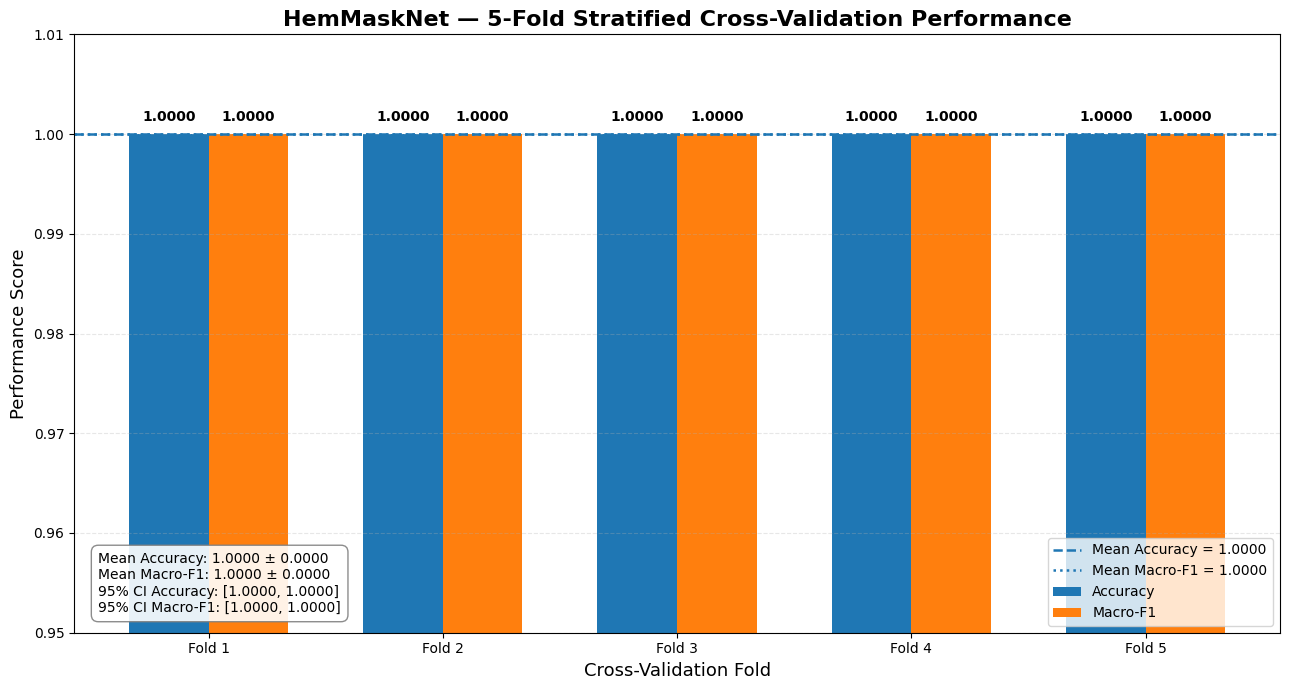

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# ACTUAL 5-FOLD CROSS-VALIDATION RESULTS
# ================================================================

folds = np.array([1, 2, 3, 4, 5])

accuracy = np.array([
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000
])

macro_f1 = np.array([
    1.0000,
    1.0000,
    1.0000,
    1.0000,
    1.0000
])

# ================================================================
# STATISTICS
# ================================================================

accuracy_mean = np.mean(accuracy)
accuracy_std = np.std(accuracy, ddof=1)

f1_mean = np.mean(macro_f1)
f1_std = np.std(macro_f1, ddof=1)

# 95% CI
# Because all values are identical, SD = 0 and therefore CI = 0.
accuracy_ci = 0.0 if accuracy_std == 0 else \
    1.96 * accuracy_std / np.sqrt(len(accuracy))

f1_ci = 0.0 if f1_std == 0 else \
    1.96 * f1_std / np.sqrt(len(macro_f1))

# ================================================================
# SINGLE COMBINED GRAPH
# ================================================================

x = np.arange(len(folds))
width = 0.34

fig, ax = plt.subplots(figsize=(13, 7))

bars_accuracy = ax.bar(
    x - width / 2,
    accuracy,
    width,
    label="Accuracy"
)

bars_f1 = ax.bar(
    x + width / 2,
    macro_f1,
    width,
    label="Macro-F1"
)

# ================================================================
# VALUE LABELS
# ================================================================

for bars in [bars_accuracy, bars_f1]:
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.001,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# ================================================================
# MEAN LINES
# ================================================================

ax.axhline(
    accuracy_mean,
    linestyle="--",
    linewidth=1.8,
    label=f"Mean Accuracy = {accuracy_mean:.4f}"
)

ax.axhline(
    f1_mean,
    linestyle=":",
    linewidth=1.8,
    label=f"Mean Macro-F1 = {f1_mean:.4f}"
)

# ================================================================
# AXIS SETTINGS
# ================================================================

ax.set_xlabel(
    "Cross-Validation Fold",
    fontsize=13
)

ax.set_ylabel(
    "Performance Score",
    fontsize=13
)

ax.set_title(
    "HemMaskNet — 5-Fold Stratified Cross-Validation Performance",
    fontsize=16,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"Fold {i}" for i in folds]
)

# Important because values are very close to 1.0
ax.set_ylim(
    0.95,
    1.01
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="lower right",
    fontsize=10
)

# ================================================================
# STATISTICAL SUMMARY INSIDE THE SAME GRAPH
# ================================================================

summary_text = (
    f"Mean Accuracy: {accuracy_mean:.4f} ± {accuracy_std:.4f}\n"
    f"Mean Macro-F1: {f1_mean:.4f} ± {f1_std:.4f}\n"
    f"95% CI Accuracy: [{accuracy_mean - accuracy_ci:.4f}, "
    f"{accuracy_mean + accuracy_ci:.4f}]\n"
    f"95% CI Macro-F1: [{f1_mean - f1_ci:.4f}, "
    f"{f1_mean + f1_ci:.4f}]"
)

ax.text(
    0.02,
    0.03,
    summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()

# ================================================================
# SAVE HIGH-RESOLUTION FIGURE
# ================================================================

plt.savefig(
    "HemMaskNet_5Fold_CV_Combined.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "HemMaskNet_5Fold_CV_Combined.pdf",
    bbox_inches="tight"
)

plt.show()